# Notebook 05b — LiRA Attack

Offline LiRA with K shadow LSTMs initialised from target weights (grey-box threat model).
Requires NB05a to have been run first (`logs/05a_target_deltas.npz`).

In [1]:
%load_ext autoreload
%autoreload 2


In [ ]:
import sys
sys.path.insert(0, '..')

import json, time, logging
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from sklearn.metrics import roc_curve, auc as sk_auc

from src.data.auth_dataset   import load_auth_dataset, normalize_auth
from src.models.gait_cnn    import GaitCNN
from src.models.auth_model  import AuthModel
from src.attacks.lira_shadow import (
    ShadowLSTM, compute_subject_scores, all_deltas,
    train_shadow_models, lira_eval, tpr_at_fpr,
)

DATA_ROOT  = Path('../data')
LOG_DIR    = Path('../logs')
CKPT_DIR   = Path('../checkpoints')
RESULT_DIR = Path('../results')
BATCH      = 512
DEVICE     = torch.device('cpu')

K_LIRA      = 32  # <<< RUNNER INJECTS THIS
LIRA_EPOCHS = 3  # <<< RUNNER INJECTS THIS
DROPOUT     = 0.3   # must match NB03 DROPOUT

log = logging.getLogger('nb05b')
log.setLevel(logging.DEBUG)
log.handlers.clear()
fh = logging.FileHandler(LOG_DIR / '05b_lira_attack.log', mode='w')
fh.setFormatter(logging.Formatter('%(asctime)s  %(message)s', datefmt='%H:%M:%S'))
sh = logging.StreamHandler()
sh.setFormatter(logging.Formatter('%(message)s'))
log.addHandler(fh); log.addHandler(sh)
log.info(f'=== Notebook 05b — LiRA Attack  K={K_LIRA} epochs={LIRA_EPOCHS} ===')
# ── dataset config ──
import sys as _sys; _sys.path.insert(0, '..')
from src.utils.config_loader import get_dataset, dataset_dirs, dataset_files
from src.data.pairs_loader   import load_auth_pairs, load_attribution, build_pair_subjects_train, build_pair_subjects_test

DATASET = 'whuGAIT'  # <<< RUNNER INJECTS THIS
# Per-dataset subdirectories — isolates all artifacts by dataset
_ds_dirs   = dataset_dirs(Path('../logs'), Path('../checkpoints'), artifacts_base=Path('../artifacts'), results_base=Path('../results'), dataset=DATASET)
LOG_DIR    = _ds_dirs['logs']
ARTIFACT_DIR = _ds_dirs['artifacts']
CKPT_DIR   = _ds_dirs['checkpoints']
RESULT_DIR = _ds_dirs['results']
CKPT_TARGET = ARTIFACT_DIR / f'05b_lira_target_shadows_{DATASET}.json'
PATHS   = dataset_files(LOG_DIR, CKPT_DIR, artifacts_dir=ARTIFACT_DIR)

with open(PATHS['split_json']) as _f:
    _split = json.load(_f)
member_ids    = _split['train_ids']
nonmember_ids = _split['held_out_ids']
N_CLASSES     = len(member_ids)
member_id_set    = set(member_ids)
nonmember_id_set = set(nonmember_ids)
log.info(f'Dataset: {DATASET}  |  N_CLASSES: {N_CLASSES}')

## Section 1 — Load Data

In [ ]:
# Target delta dicts from NB05a (three variants, all subjects)
d = np.load(ARTIFACT_DIR / '05a_target_deltas.npz')
member_list    = d['member_ids'].tolist()
nonmember_list = d['nonmember_ids'].tolist()

all_raw_targets = {**dict(zip(d['member_ids'].tolist(), d['member_raw'].tolist())),
                   **dict(zip(d['nonmember_ids'].tolist(), d['nonmember_raw'].tolist()))}
all_lf_targets  = {**dict(zip(d['member_ids'].tolist(), d['member_lf'].tolist())),
                   **dict(zip(d['nonmember_ids'].tolist(), d['nonmember_lf'].tolist()))}
all_mf_targets  = {**dict(zip(d['member_ids'].tolist(), d['member_mf'].tolist())),
                   **dict(zip(d['nonmember_ids'].tolist(), d['nonmember_mf'].tolist()))}

# Also load simple delta AUC from NB05a for gain comparison
nb04 = np.load(ARTIFACT_DIR / '04_mia_scores.npz')
all_scores = np.concatenate([nb04['member_scores'], nb04['nonmember_scores']])
all_labels = np.concatenate([np.ones(len(nb04['member_scores'])), np.zeros(len(nb04['nonmember_scores']))])
fpr_base, tpr_base, _ = roc_curve(all_labels, all_scores)
mia_auc   = sk_auc(fpr_base, tpr_base)
tpr_at_10 = tpr_at_fpr(fpr_base, tpr_base, 0.10)



print(f'Members: {len(member_list)}  Non-members: {len(nonmember_list)}')
print(f'Simple delta baseline: AUC={mia_auc:.4f}  TPR@0.10={tpr_at_10:.3f}')

In [4]:
# CNN features (re-computed — ~30s, avoids storing large tensors between notebooks)
norm_data = np.load(PATHS['norm_stats'])
norm_mean2, norm_std2 = norm_data['mean'], norm_data['std']

# Read encoder n_classes from metadata (cross-dataset: source may differ from N_CLASSES)
_cnn_n = json.load(open(PATHS['cnn_meta']))['n_classes'] if PATHS['cnn_meta'].exists() else N_CLASSES
cnn_base = GaitCNN(n_classes=_cnn_n)
cnn_base.load_state_dict(torch.load(PATHS['cnn_ckpt'], map_location='cpu'))
cnn_base.eval()

target_auth = AuthModel(cnn_base).to(DEVICE)
target_auth.load_state_dict(torch.load(PATHS['auth_ckpt'], map_location='cpu'))
target_auth.eval()

X1_tr, X2_tr, y_tr = load_auth_pairs('train', DATA_ROOT, ARTIFACT_DIR)
X1_n, X2_n, _      = normalize_auth(X1_tr, X2_tr, (norm_mean2, norm_std2))

X1_te, X2_te, y_te = load_auth_pairs('test',  DATA_ROOT, ARTIFACT_DIR)
X1_te_n, X2_te_n, _ = normalize_auth(X1_te, X2_te, (norm_mean2, norm_std2))

subj_win1_tr, subj_win2_tr = load_attribution('train', ARTIFACT_DIR)
subj_win1_te, subj_win2_te = load_attribution('test',  ARTIFACT_DIR)
pair_subjects    = build_pair_subjects_train(y_tr, subj_win1_tr, subj_win2_tr, member_id_set, logs_dir=LOG_DIR)
te_pair_subjects = build_pair_subjects_test( y_te, subj_win1_te, subj_win2_te, nonmember_id_set, logs_dir=LOG_DIR)

print('Precomputing CNN features...')
feats_list = []
with torch.no_grad():
    for s in range(0, len(X1_n), BATCH):
        e = min(s + BATCH, len(X1_n))
        feats_list.append(torch.cat([
            cnn_base.get_feature_maps(torch.from_numpy(X1_n[s:e]).float()),
            cnn_base.get_feature_maps(torch.from_numpy(X2_n[s:e]).float()),
        ], dim=1).half().cpu())
all_feats = torch.cat(feats_list, dim=0)

te_feats_list = []
with torch.no_grad():
    for s in range(0, len(X1_te_n), BATCH):
        e = min(s + BATCH, len(X1_te_n))
        te_feats_list.append(torch.cat([
            cnn_base.get_feature_maps(torch.from_numpy(X1_te_n[s:e]).float()),
            cnn_base.get_feature_maps(torch.from_numpy(X2_te_n[s:e]).float()),
        ], dim=1).half().cpu())
te_feats = torch.cat(te_feats_list, dim=0)
print(f'Train feats {tuple(all_feats.shape)}  Test feats {tuple(te_feats.shape)}')

Precomputing CNN features...
Train feats (60000, 32, 128)  Test feats (10000, 32, 128)


## Section 2 — Shadow Model Training

The attacker knows the model architecture and has access to the target model weights. Each shadow LSTM is initialised from the target's weights and fine-tuned on a random 50% subset of members.

Section 05c compares this against the black-box assumption (random init).

In [5]:
# K shadow LSTMs, each initialised from target weights, trained on 50% of members
target_state = {
    'lstm': target_auth.lstm.state_dict(),
    'fc':   target_auth.fc.state_dict(),
}

out_raw, out_lf, out_mf = train_shadow_models(
    all_feats, y_tr, pair_subjects, member_list,
    te_feats,  y_te, te_pair_subjects, nonmember_list,
    K=K_LIRA, epochs=LIRA_EPOCHS,
    init_mode='target', target_state=target_state,
    split_mode='member_aware',
    pair_subjects_w2=subj_win2_tr,
    checkpoint_path=CKPT_TARGET,
    batch_size=BATCH, device=str(DEVICE), log=log,
    dropout=DROPOUT,
)

valid_m = [s for s in member_list if s in out_raw and len(out_raw[s]) >= 5]
log.info(f'Valid members (≥5 OUT estimates): {len(valid_m)}/{len(member_list)}')
print(f'Valid members for LiRA: {len(valid_m)}/{len(member_list)}')

No checkpoint found — starting from scratch.
Training 32 shadow LSTMs (init=target, split=member_aware, epochs=3)...
  [ 1/32]  0.6min  ETA=18.3min
  [ 8/32]  4.5min  ETA=13.6min
  [16/32]  9.0min  ETA=9.0min
  [24/32]  14.0min  ETA=4.7min
  [32/32]  19.2min  ETA=0.0min
Done in 19.2 min
Valid members (≥5 OUT estimates): 21/21


Valid members for LiRA: 21/21


## Section 3 — LiRA Scoring

For each subject, fit a Gaussian on their shadow OUT-deltas, then score the
target delta against it:

$$\text{score}(s) = \Phi\!\left(\delta_{\text{target}}(s)\;\big|\;\mu_{\text{out}}(s),\,\sigma_{\text{out}}(s)\right)$$

A high score means the target delta is unusually high relative to what OUT shadows
produce → the subject was likely seen during training (member).


In [6]:
fpr_raw, tpr_raw, auc_raw, tpr10_raw, tpr20_raw, scores_raw, m_raw, nm_raw =     lira_eval(out_raw, all_raw_targets, member_list, nonmember_list)

fpr_lf, tpr_lf, auc_lf, tpr10_lf, tpr20_lf, scores_lf, m_lf, nm_lf =     lira_eval(out_lf, all_lf_targets, member_list, nonmember_list)

fpr_mf, tpr_mf, auc_mf, tpr10_mf, tpr20_mf, scores_mf, m_mf, nm_mf =     lira_eval(out_mf, all_mf_targets, member_list, nonmember_list)

print(f'{"Variant":<18}  {"AUC":>6}  {"ΔAUC":>6}  {"TPR@0.10":>9}')
print('-' * 46)
print(f'{"simple delta":<18}  {mia_auc:.4f}  {"—":>6}  {tpr_at_10:.3f}')
for name, auc_v, t10 in [('LiRA raw', auc_raw, tpr10_raw),
                          ('LiRA logit-first', auc_lf, tpr10_lf),
                          ('LiRA mean-first',  auc_mf, tpr10_mf)]:
    print(f'{name:<18}  {auc_v:.4f}  {auc_v-mia_auc:+.4f}  {t10:.3f}')

# mean-first is the primary reported variant (best empirical performance)
lira_auc       = auc_mf
lira_tpr_at_10 = tpr10_mf
lira_tpr_at_20 = tpr20_mf
log.info(f'LiRA  raw={auc_raw:.4f}  lf={auc_lf:.4f}  mf={auc_mf:.4f}')

LiRA  raw=0.8995  lf=0.7407  mf=0.8783


Variant                AUC    ΔAUC   TPR@0.10
----------------------------------------------
simple delta        0.9153       —  0.476
LiRA raw            0.8995  -0.0159  0.524
LiRA logit-first    0.7407  -0.1746  0.571
LiRA mean-first     0.8783  -0.0370  0.524


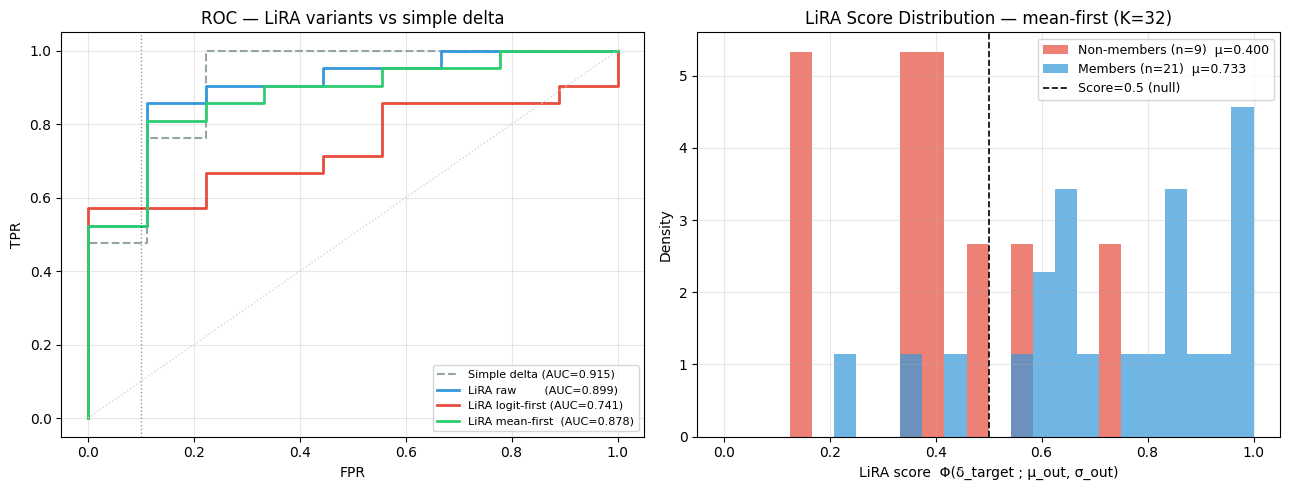

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(fpr_base, tpr_base, color='#95a5a6', linewidth=1.5, linestyle='--',
        label=f'Simple delta (AUC={mia_auc:.3f})')
ax.plot(fpr_raw, tpr_raw, color='#3498db', linewidth=2, label=f'LiRA raw        (AUC={auc_raw:.3f})')
ax.plot(fpr_lf,  tpr_lf,  color='#e74c3c', linewidth=2, label=f'LiRA logit-first (AUC={auc_lf:.3f})')
ax.plot(fpr_mf,  tpr_mf,  color='#2ecc71', linewidth=2, label=f'LiRA mean-first  (AUC={auc_mf:.3f})')
ax.plot([0,1],[0,1], color='lightgray', linestyle=':', linewidth=1)
ax.axvline(0.10, color='black', linestyle=':', linewidth=1, alpha=0.4)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — LiRA variants vs simple delta')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
bins = np.linspace(0, 1, 25)
ax.hist(nm_mf[:,1], bins=bins, alpha=0.7, color='#e74c3c',
        label=f'Non-members (n={len(nm_mf)})  μ={nm_mf[:,1].mean():.3f}', density=True)
ax.hist(m_mf[:,1],  bins=bins, alpha=0.7, color='#3498db',
        label=f'Members (n={len(m_mf)})  μ={m_mf[:,1].mean():.3f}',     density=True)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='Score=0.5 (null)')
ax.set_xlabel('LiRA score  Φ(δ_target ; μ_out, σ_out)')
ax.set_ylabel('Density')
ax.set_title(f'LiRA Score Distribution — mean-first (K={K_LIRA})')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULT_DIR / '05b_lira_results.png', dpi=150)
plt.show()

## Section 4 — Per-Subject Evaluation at FPR ≤ 0.10

In [ ]:
TARGET_FPR = 0.10

nb04_raw = {int(i): float(d) for i, d in zip(nb04['member_ids'], nb04['member_scores'])}
nb04_raw.update({int(i): float(d) for i, d in zip(nb04['nonmember_ids'], nb04['nonmember_scores'])})

variants_info = [
    ('Simple-D', nb04_raw,   mia_auc, tpr_at_10),
    ('LiRA-raw', scores_raw, auc_raw, tpr10_raw),
    ('LiRA-lf',  scores_lf,  auc_lf,  tpr10_lf),
    ('LiRA-mf',  scores_mf,  auc_mf,  tpr10_mf),
]

def op_point(score_dict, m_list, nm_list, target_fpr):
    sids, scores, labels = [], [], []
    for sid in m_list:
        if sid in score_dict: sids.append(sid); scores.append(score_dict[sid]); labels.append(1)
    for sid in nm_list:
        if sid in score_dict: sids.append(sid); scores.append(score_dict[sid]); labels.append(0)
    if len(scores) < 2 or len(set(labels)) < 2:
        return 0.5, 0.5, target_fpr
    fpr_a, tpr_a, thr_a = roc_curve(np.array(labels), np.array(scores))
    idx = min(max(0, int(np.searchsorted(fpr_a, target_fpr, side='right')) - 1), len(thr_a)-1)
    return float(thr_a[idx]), float(tpr_a[idx]), float(fpr_a[idx])

op = {name: op_point(sd, member_list, nonmember_list, TARGET_FPR)
      for name, sd, *_ in variants_info}

member_set = set(member_list)
hdr = f"{'ID':>5}  " + "  ".join(f"{n+' sc':>10}  {'pred':>4}" for n, *_ in variants_info) + "  True"
print(hdr); print('-' * len(hdr))

per_subject_rows = []
for group, sids in [('-- members --', sorted(member_list)), ('-- non-members --', sorted(nonmember_list))]:
    print(f'\n{group}')
    for sid in sids:
        true_lbl = 'M' if sid in member_set else 'NM'
        line = f'{sid:>5}  '
        row  = {'subject_id': int(sid), 'true_label': 'member' if true_lbl == 'M' else 'non-member'}
        for name, sd, *_ in variants_info:
            score = sd.get(sid)
            thr   = op[name][0]
            if score is not None:
                pred  = 'M' if score >= thr else 'NM'
                mark  = '+' if pred == true_lbl else 'X'
                line += f'  {score:>10.3f}  {pred+mark:>5}'
            else:
                line += f'  {"N/A":>10}  {"?":>5}'
                pred = None
            row[name] = {'score': round(score, 4) if score is not None else None, 'pred': pred}
        print(line + f'  {true_lbl}')
        per_subject_rows.append(row)

print(f'\n{"Variant":<10}  {"AUC":>6}  {"TPR@0.10":>8}')
for name, _, auc_v, t10 in variants_info:
    print(f'{name:<10}  {auc_v:.4f}  {t10:.3f}')

import json as _json
report_path = ARTIFACT_DIR / '05b_per_subject_report.json'
with open(report_path, 'w') as f:
    _json.dump({'target_fpr': TARGET_FPR,
                'variants': {n: {'auc': auc_v, 'tpr10': t10} for n, _, auc_v, t10 in variants_info},
                'per_subject': per_subject_rows}, f, indent=2)
print(f'\nSaved: {report_path}')